C:\Users\HUU THUC\AppData\Local\Temp\ipykernel_10032\3395787001.py:17: DtypeWarning: Columns (0: order_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fact = pd.read_csv("E:/Dự Án Tốt Nghiệp/PRO2291_duantotnghiep1/data/dim_fact/fact_sales.csv")


TỔNG SỐ KHÁCH HÀNG ĐÃ MUA SẮM: 64,248 người
ĐỘ TUỔI TRUNG BÌNH CỦA KHÁCH HÀNG: 46.5 tuổi


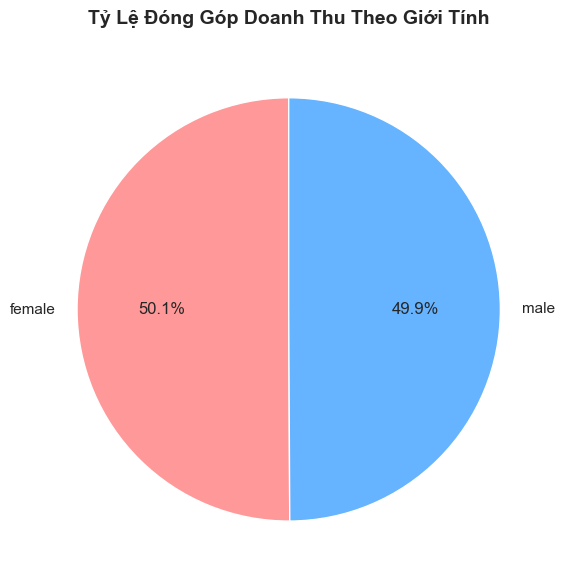

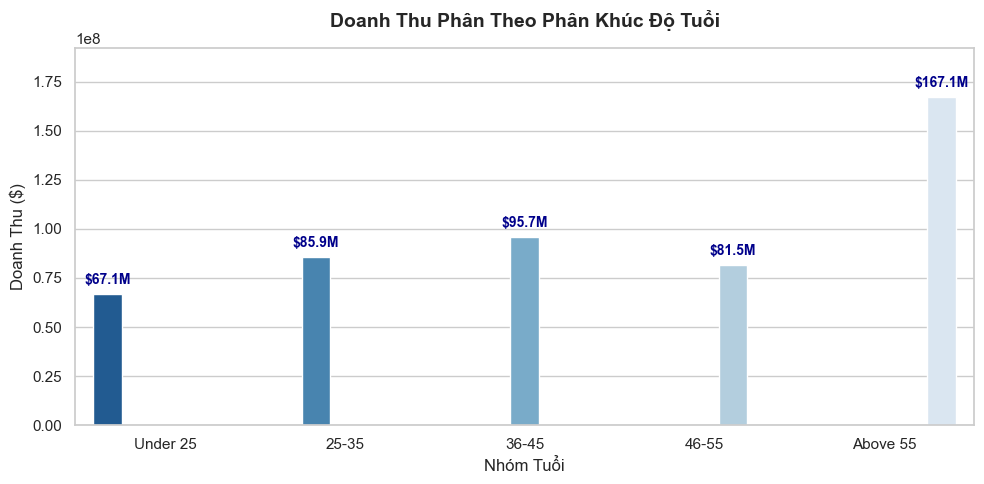

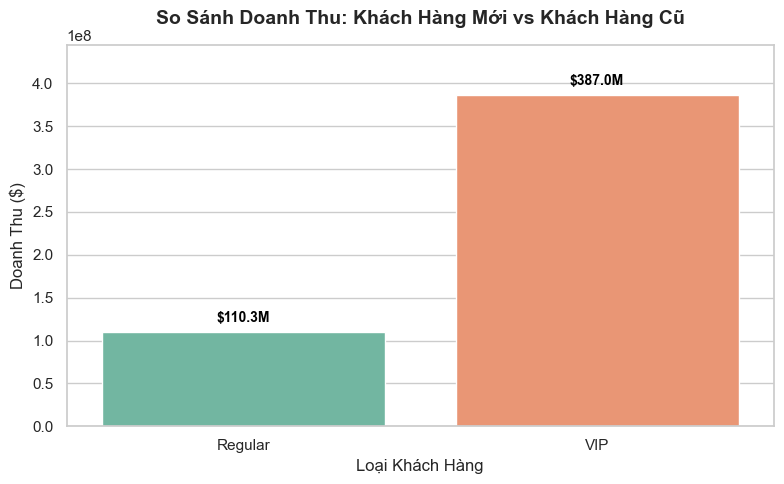

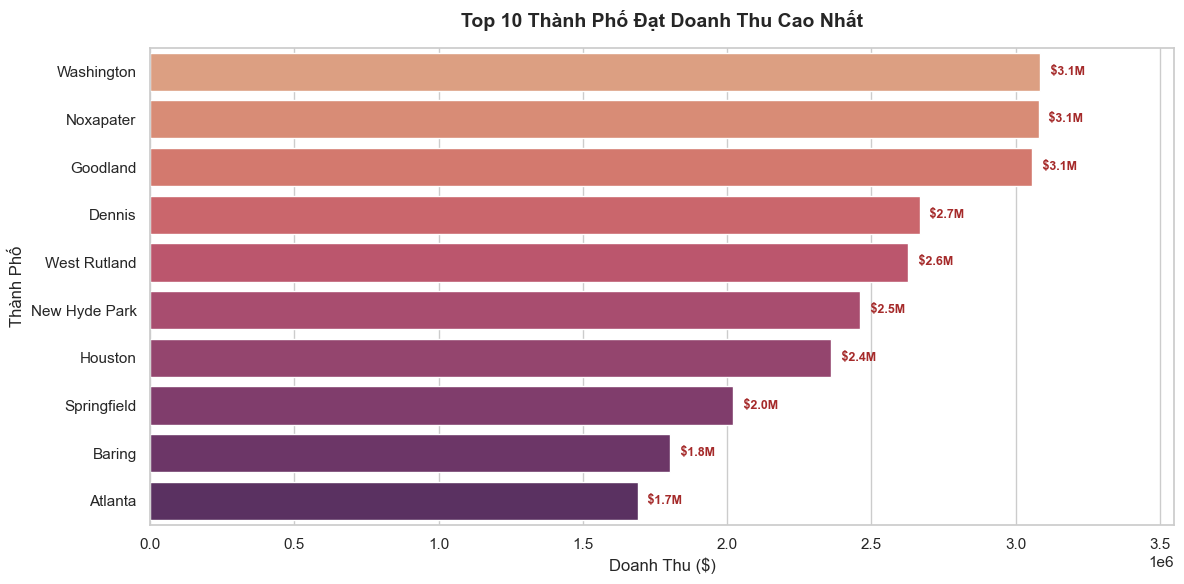

In [3]:
# ############################################################################
# DASHBOARD 2: CHÂN DUNG KHÁCH HÀNG & PHÂN KHÚC THỊ TRƯỜNG
# Sinh viên thực hiện: Nguyễn Hữu Thức  
# Trường: FPT Polytechnic Ho Chi Minh City  
# ############################################################################

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# ## 1. ĐỌC VÀ KHỚP NỐI DỮ LIỆU (MERGE DATA)

df_fact = pd.read_csv("E:/Dự Án Tốt Nghiệp/PRO2291_duantotnghiep1/data/dim_fact/fact_sales.csv")
df_customer = pd.read_csv("E:/Dự Án Tốt Nghiệp/PRO2291_duantotnghiep1/data/dim_fact/dim_customer.csv")
df_location = pd.read_csv("E:/Dự Án Tốt Nghiệp/PRO2291_duantotnghiep1/data/dim_fact/dim_location.csv")

def clean_revenue(df):
    if 'revenue' in df.columns and df['revenue'].dtype == 'object':
        df['revenue'] = df['revenue'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
    return df

df_fact = clean_revenue(df_fact)

df_merge = pd.merge(df_fact, df_customer, on='customer_id', how='inner')
df_merge = pd.merge(df_merge, df_location, on='location_id', how='inner')

# ## 2. TÍNH TOÁN CÁC CHỈ SỐ KPI

total_users = df_merge['customer_id'].nunique()
avg_age = df_merge['age'].mean()

print("===========================================")
print(f"TỔNG SỐ KHÁCH HÀNG ĐÃ MUA SẮM: {total_users:,} người")
print(f"ĐỘ TUỔI TRUNG BÌNH CỦA KHÁCH HÀNG: {avg_age:.1f} tuổi")
print("===========================================")

# ## 3. VẼ CÁC BIỂU ĐỒ TRỰC QUAN HÓA CHÂN DUNG KHÁCH HÀNG

# ----------------------------------------------------------------------
# Biểu đồ 1: Tỷ lệ doanh thu theo Giới tính (Pie Chart - Giữ nguyên vì đã có %)
# ----------------------------------------------------------------------
plt.figure(figsize=(6, 6))
gender_sales = df_merge.groupby('gender')['revenue'].sum()
plt.pie(gender_sales, labels=gender_sales.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Tỷ Lệ Đóng Góp Doanh Thu Theo Giới Tính', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('sales_by_gender.png')
plt.show()

# ----------------------------------------------------------------------
# Biểu đồ 2: Phân bố doanh thu theo nhóm tuổi (Thêm nhãn trên đầu cột)
# ----------------------------------------------------------------------
df_merge['age_group'] = pd.cut(df_merge['age'], bins=[0, 25, 35, 45, 55, 100], 
                               labels=['Under 25', '25-35', '36-45', '46-55', 'Above 55'])

plt.figure(figsize=(10, 5))
age_sales = df_merge.groupby('age_group', observed=False)['revenue'].sum().reset_index()
ax2 = sns.barplot(data=age_sales, x='age_group', y='revenue', hue='age_group', palette='Blues_r', legend=False)

# Vòng lặp thêm số liệu chi tiết ($M) lên đầu cột đứng
for p in ax2.patches:
    val = p.get_height()
    if val > 0:
        ax2.annotate(f"${val/1000000:.1f}M", 
                     (p.get_x() + p.get_width() / 2., val), 
                     ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkblue', xytext=(0, 5), textcoords='offset points')

plt.title('Doanh Thu Phân Theo Phân Khúc Độ Tuổi', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nhóm Tuổi', fontsize=12)
plt.ylabel('Doanh Thu ($)', fontsize=12)
plt.ylim(0, age_sales['revenue'].max() * 1.15)
plt.tight_layout()
plt.savefig('sales_by_age_group.png')
plt.show()

# ----------------------------------------------------------------------
# Biểu đồ 3: Doanh thu từ Khách hàng Mới vs Khách hàng Cũ (Thêm nhãn trên đầu cột)
# ----------------------------------------------------------------------
plt.figure(figsize=(8, 5))
cust_type_sales = df_merge.groupby('customer_type')['revenue'].sum().reset_index()
ax3 = sns.barplot(data=cust_type_sales, x='customer_type', y='revenue', hue='customer_type', palette='Set2', legend=False)

# Vòng lặp thêm số liệu chi tiết ($M) lên đầu cột đứng
for p in ax3.patches:
    val = p.get_height()
    if val > 0:
        ax3.annotate(f"${val/1000000:.1f}M", 
                     (p.get_x() + p.get_width() / 2., val), 
                     ha='center', va='bottom', fontsize=10, fontweight='bold', color='black', xytext=(0, 5), textcoords='offset points')

plt.title('So Sánh Doanh Thu: Khách Hàng Mới vs Khách Hàng Cũ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Loại Khách Hàng', fontsize=12)
plt.ylabel('Doanh Thu ($)', fontsize=12)
plt.ylim(0, cust_type_sales['revenue'].max() * 1.15)
plt.tight_layout()
plt.savefig('sales_by_customer_type.png')
plt.show()

# ----------------------------------------------------------------------
# Biểu đồ 4: Top 10 Thành phố có sức mua lớn nhất (Thêm nhãn vào bên phải cột ngang)
# ----------------------------------------------------------------------
plt.figure(figsize=(12, 6))
city_sales = df_merge.groupby('city')['revenue'].sum().reset_index()
city_sales_top10 = city_sales.sort_values(by='revenue', ascending=False).head(10)

ax4 = sns.barplot(data=city_sales_top10, x='revenue', y='city', hue='city', palette='flare', legend=False)

# Vòng lặp thêm số liệu chi tiết ($M) vào cuối thanh cột ngang
for p in ax4.patches:
    val = p.get_width()
    if val > 0:
        ax4.annotate(f" ${val/1000000:.1f}M", 
                     (val, p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', fontsize=9, fontweight='bold', color='brown', xytext=(5, 0), textcoords='offset points')

plt.title('Top 10 Thành Phố Đạt Doanh Thu Cao Nhất', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Doanh Thu ($)', fontsize=12)
plt.ylabel('Thành Phố', fontsize=12)
plt.xlim(0, city_sales_top10['revenue'].max() * 1.15) # Mở rộng trục X sang phải để không bị khuất chữ
plt.tight_layout()
plt.savefig('top_10_cities.png')
plt.show()